# Latency Analysis (Agentic Oracle)

Consolidation of **5 runs** of the full pipeline (CSV → blockchain) over the
synthetic benchmark. The focus is the **end-to-end latency** and its breakdown by
phase (Sensor, Validator, Governance, Blockchain), with statistical analysis.

The system decisions are deterministic (identical across runs), so the
repetitions characterize the **performance variability**, not the decisions.

**Data:** `../results/results_v2_1/rodada_1` … `rodada_5` (*rodada* means run). Every chart
is saved in high resolution to `../results/results_v2_1/latency_analysis/`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Publication style
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
})

RESULTS = Path("../results/results_v2_1")
OUT = RESULTS / "latency_analysis"
OUT.mkdir(parents=True, exist_ok=True)

PHASES = ["sensor", "validator", "governance", "blockchain"]
LAT_COLS = [f"lat_{p}_s" for p in PHASES]
PHASE_LABEL = {"sensor": "Sensor", "validator": "Validator",
               "governance": "Governance", "blockchain": "Blockchain"}


## 1. Data loading

In [2]:
def load_latency(results_dir=RESULTS, pattern="rodada_*"):
    manifests = sorted(results_dir.glob(f"{pattern}/**/_manifest.json"))
    rows = []
    for m in manifests:
        d = json.loads(m.read_text(encoding="utf-8"))
        run = m.relative_to(results_dir).parts[0]
        # short label: rodada_N
        short = run.split("_run_")[0] if "_run_" in run else run
        for s in d.get("sessions", []):
            if s.get("status") != "ok" or s.get("lat_blockchain_s") is None:
                continue
            rows.append({
                "run": short,
                "vehicle": s.get("vehicle"),
                "trip": s.get("viagem"),
                "scenario": s.get("scenario"),
                "decision": s.get("governance_decision"),
                "distance_km": s.get("distance_km"),
                "elapsed_s": s.get("elapsed_s"),
                **{p: s.get(f"lat_{p}_s") for p in PHASES},
            })
    df = pd.DataFrame(rows)
    # agentic time (3 LLM phases) vs blockchain
    df["agentic_s"] = df[["sensor", "validator", "governance"]].sum(axis=1)
    df["pipeline_s"] = df[PHASES].sum(axis=1)
    return df

df = load_latency()
print(f"Runs: {sorted(df['run'].unique())}")
print(f"Sessions with latency: {len(df)}")
df.head()


Runs: ['rodada_1', 'rodada_2', 'rodada_3', 'rodada_4', 'rodada_5']
Sessions with latency: 360


,run,vehicle,trip,scenario,decision,distance_km,elapsed_s,sensor,validator,governance,blockchain,agentic_s,pipeline_s
0,rodada_1,creta,1,01_viagem_perfeita,denied,5.558,25.43,3.334,3.227,2.722,12.766,9.283,22.049
1,rodada_1,creta,1,02_eco_motorista,approved,9.847,31.12,3.497,3.173,3.350,18.984,10.020,29.004
2,rodada_1,creta,1,03_viagem_etanol,denied,5.558,27.10,4.580,3.262,2.726,15.384,10.568,25.952
3,rodada_1,creta,1,04_falha_sensor_maf_mas_valido,denied,5.558,25.12,3.766,3.238,2.710,13.062,9.714,22.776
4,rodada_1,creta,1,05_motorista_agressivo,denied,19.781,27.10,4.108,3.144,2.759,15.693,10.011,25.704


## 2. Descriptive statistics per phase

Mean, standard deviation, median, 95th percentile and coefficient of variation (CV = std/mean).
The CV measures the relative stability of each phase.


In [3]:
def describe_phase(df):
    recs = []
    for p in PHASES + ["agentic", "pipeline"]:
        col = p if p in ("agentic", "pipeline") else p
        col = {"agentic": "agentic_s", "pipeline": "pipeline_s"}.get(p, p)
        x = df[col].dropna()
        recs.append({
            "phase": PHASE_LABEL.get(p, p.capitalize()),
            "mean (s)": x.mean(),
            "std (s)": x.std(),
            "median (s)": x.median(),
            "p95 (s)": x.quantile(0.95),
            "min (s)": x.min(),
            "max (s)": x.max(),
            "CV (%)": 100 * x.std() / x.mean(),
        })
    return pd.DataFrame(recs).set_index("phase").round(2)

desc = describe_phase(df)
desc.to_csv(OUT / "latency_descriptive_stats.csv", encoding="utf-8")
desc


,mean (s),std (s),median (s),p95 (s),min (s),max (s),CV (%)
phase,,,,,,,
Sensor,3.83,0.29,3.80,4.11,3.29,7.74,7.55
Validator,3.13,0.13,3.14,3.33,2.87,3.45,4.18
Governance,2.98,0.20,2.92,3.38,2.68,3.44,6.67
Blockchain,14.33,2.26,13.28,19.27,11.51,20.31,15.76
Agentic,9.94,0.38,9.86,10.54,9.20,14.32,3.87
Pipeline,24.27,2.50,23.10,29.45,21.12,31.09,10.29


## 3. Where the time goes — pipeline composition

Breakdown of the mean pipeline latency (sum of the four phases).


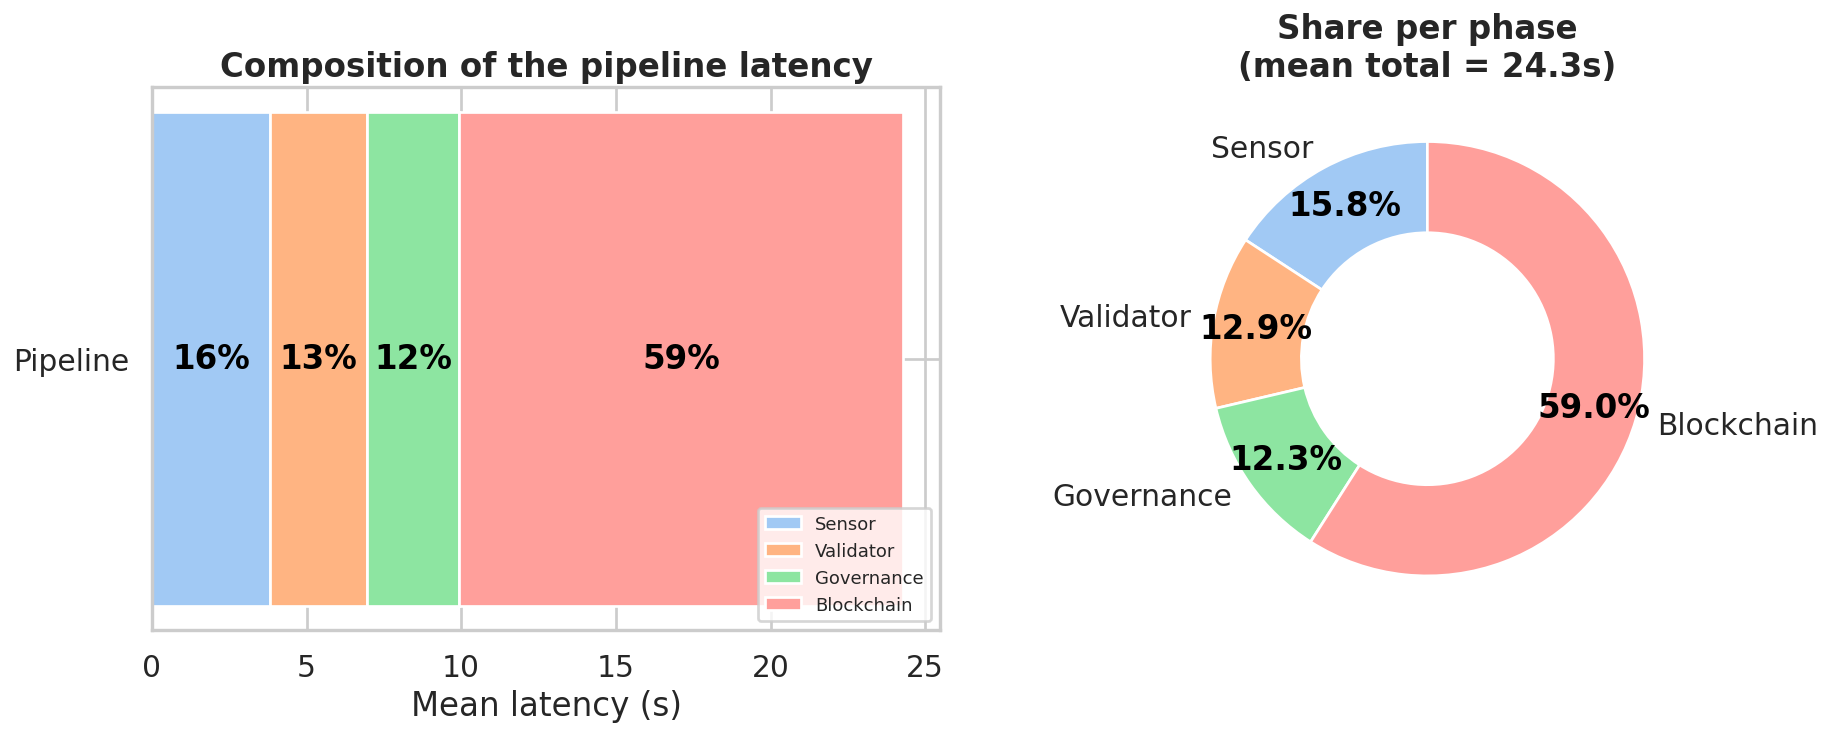

Agentic time (LLM): 9.9s (41%)
Blockchain time   : 14.3s (59%)


In [4]:
means = df[PHASES].mean()
total = means.sum()
pct = 100 * means / total

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) stacked horizontal bars — composition
left = 0
colors = sns.color_palette("pastel", len(PHASES))
for p, c in zip(PHASES, colors):
    axes[0].barh(["Pipeline"], [means[p]], left=left, color=c, label=PHASE_LABEL[p])
    axes[0].text(left + means[p] / 2, 0, f"{pct[p]:.0f}%", ha="center", va="center",
                 color="black", fontweight="bold")
    left += means[p]
axes[0].set_xlabel("Mean latency (s)")
axes[0].set_title("Composition of the pipeline latency")
axes[0].legend(loc="lower right", fontsize=10)

# (b) donut — percentage share
wedges, _, autotexts = axes[1].pie(
    means, labels=[PHASE_LABEL[p] for p in PHASES], autopct="%1.1f%%",
    startangle=90, colors=colors, pctdistance=0.8,
    wedgeprops=dict(width=0.42, edgecolor="white"))
for t in autotexts:
    t.set_fontweight("bold"); t.set_color("black")
axes[1].set_title(f"Share per phase\n(mean total = {total:.1f}s)")

fig.tight_layout()
fig.savefig(OUT / "latency_composition.png")
plt.show()
print(f"Agentic time (LLM): {means[['sensor','validator','governance']].sum():.1f}s "
      f"({100*means[['sensor','validator','governance']].sum()/total:.0f}%)")
print(f"Blockchain time   : {means['blockchain']:.1f}s ({pct['blockchain']:.0f}%)")


## 4. Latency distribution per phase

Box plot + violin show the spread, median and tails of each phase.


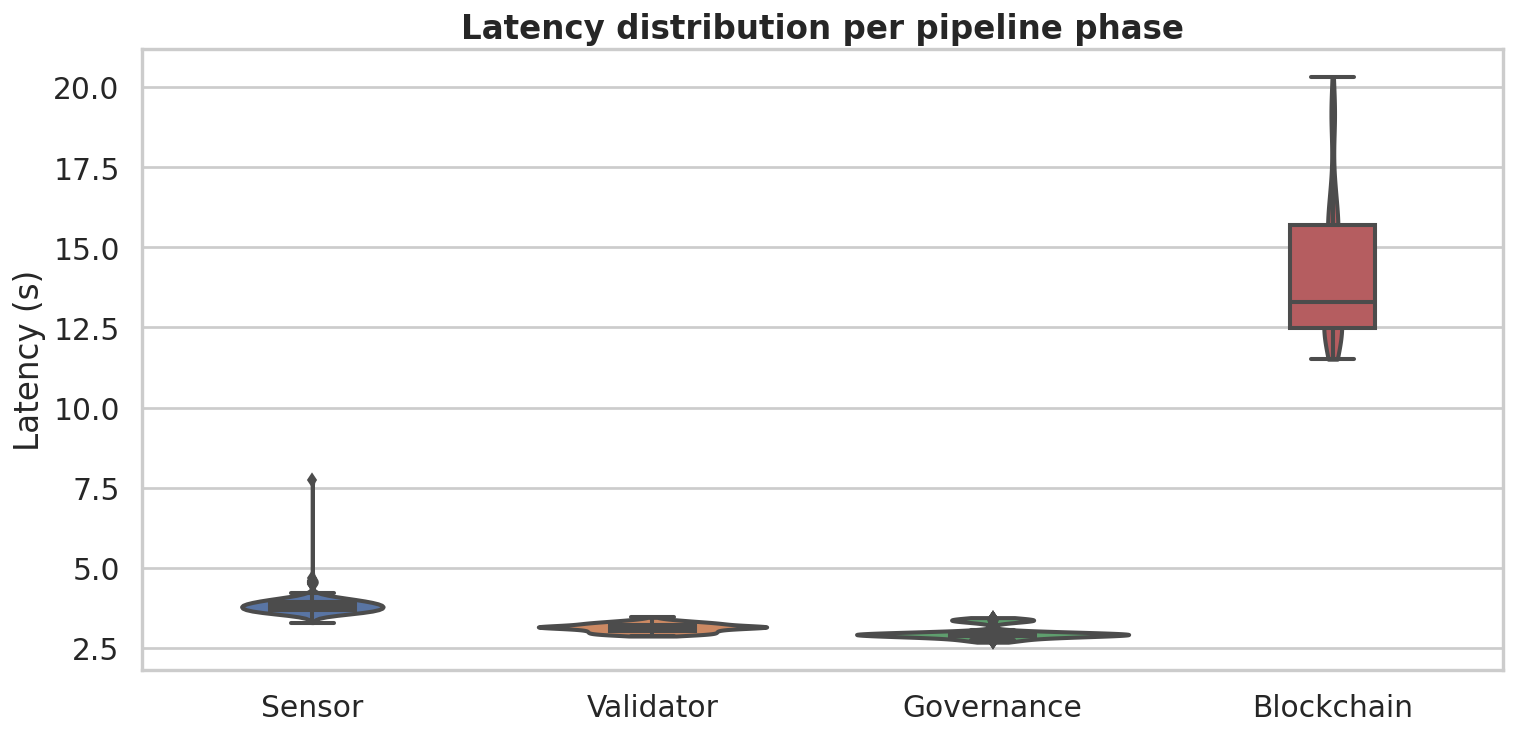

In [5]:
long = df.melt(id_vars=["run", "decision"], value_vars=PHASES,
               var_name="phase", value_name="latency")
long["phase"] = long["phase"].map(PHASE_LABEL)
order = [PHASE_LABEL[p] for p in PHASES]

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=long, x="phase", y="latency", order=order, inner=None,
               cut=0, alpha=0.35, ax=ax)
sns.boxplot(data=long, x="phase", y="latency", order=order, width=0.25,
            showcaps=True, boxprops={"zorder": 2}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Latency (s)")
ax.set_title("Latency distribution per pipeline phase")
fig.tight_layout()
fig.savefig(OUT / "phase_distribution.png")
plt.show()


## 5. End-to-end latency

Distribution of the total time per session (`elapsed_s`).


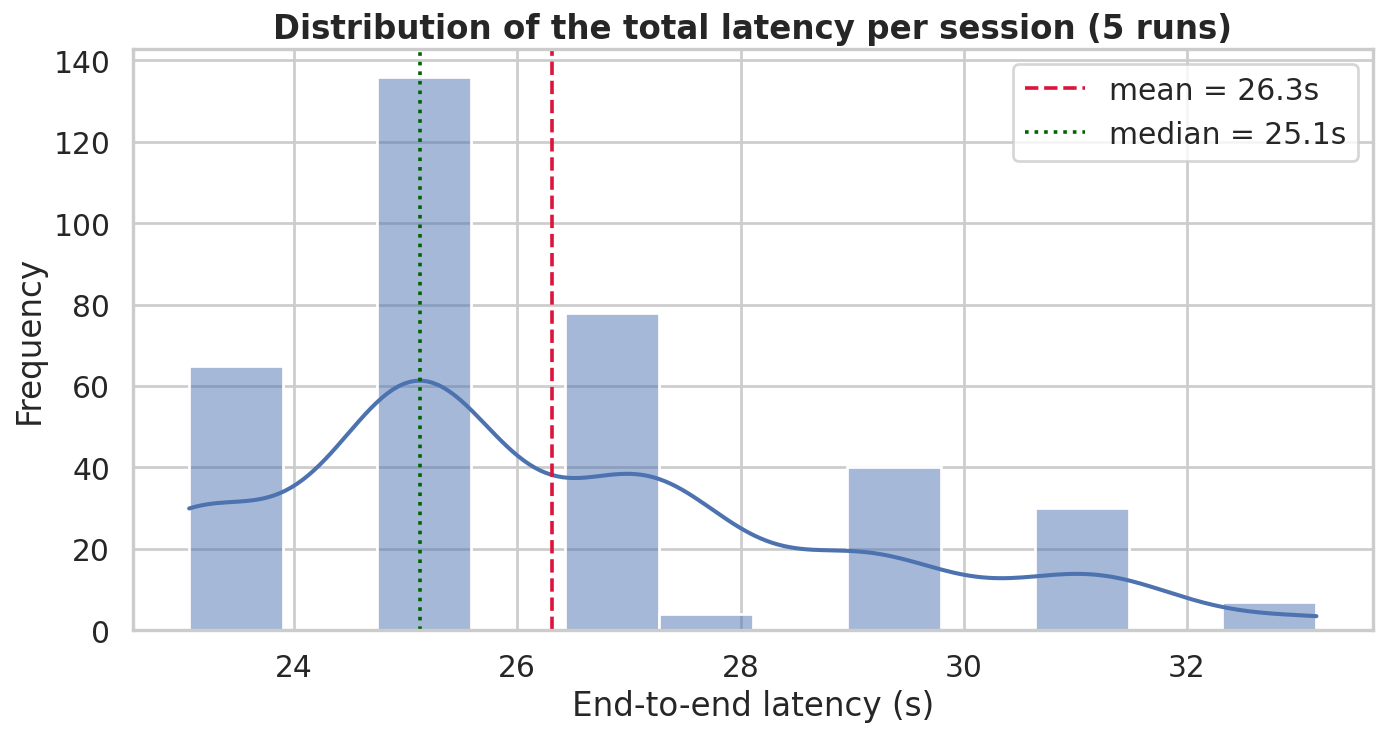

count    360.00
mean      26.32
std        2.50
min       23.06
25%       25.10
50%       25.13
75%       27.13
max       33.16
Name: elapsed_s, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(df["elapsed_s"], bins=12, kde=True, color=sns.color_palette("deep")[0], ax=ax)
ax.axvline(df["elapsed_s"].mean(), color="crimson", ls="--", lw=2,
           label=f"mean = {df['elapsed_s'].mean():.1f}s")
ax.axvline(df["elapsed_s"].median(), color="darkgreen", ls=":", lw=2,
           label=f"median = {df['elapsed_s'].median():.1f}s")
ax.set_xlabel("End-to-end latency (s)"); ax.set_ylabel("Frequency")
ax.set_title("Distribution of the total latency per session (5 runs)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "total_latency_distribution.png")
plt.show()
print(df["elapsed_s"].describe().round(2))


## 6. Performance stability across runs

Decisions are identical across runs. Here we check whether the **performance**
(latency) is also stable, using the **Kruskal-Wallis** test (non-parametric) to check
for a significant difference in the pipeline latency (sum of the phases) across the 5 runs.


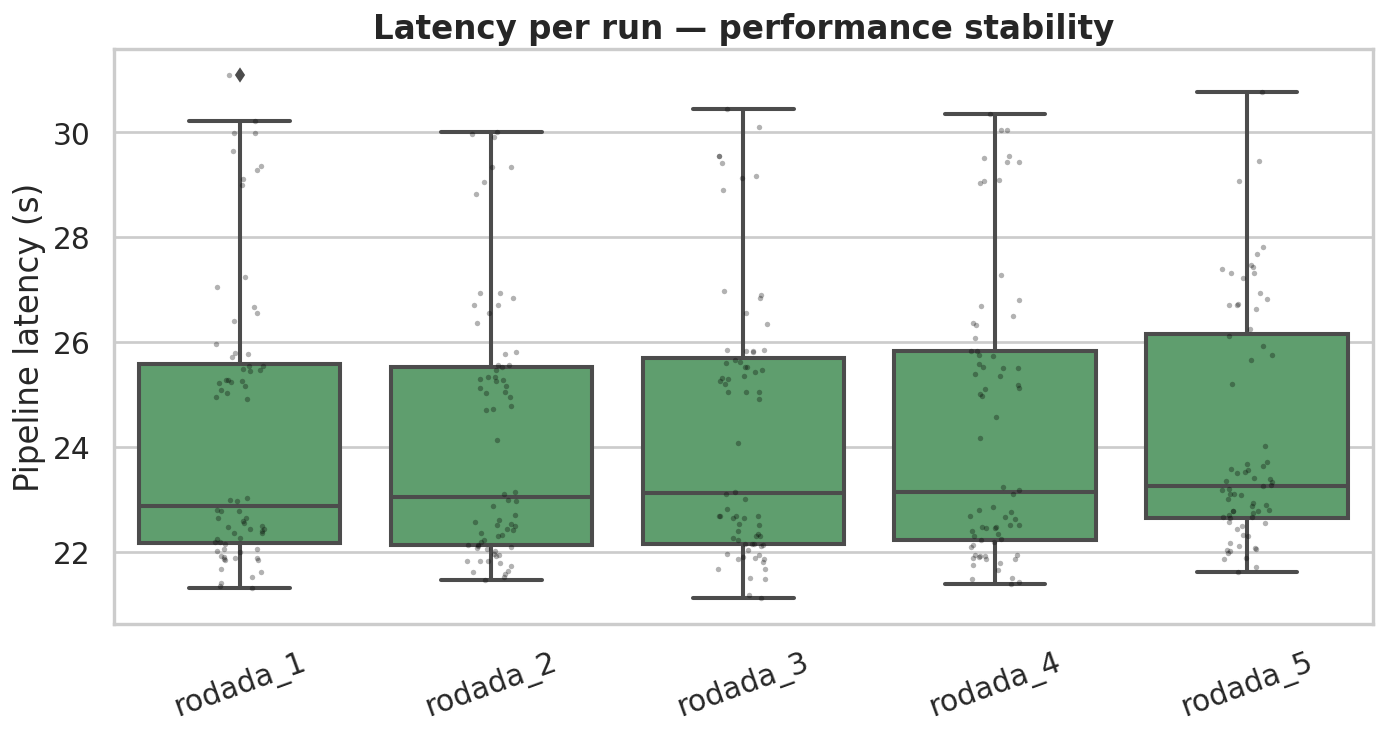

Kruskal-Wallis: H = 1.864, p = 0.7608
=> No significant difference across runs (p > 0.05): stable performance.

Mean ± std per run (s):
           mean   std
run                  
rodada_1  24.30  2.67
rodada_2  24.18  2.44
rodada_3  24.30  2.52
rodada_4  24.39  2.67
rodada_5  24.18  2.22


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x="run", y="pipeline_s", ax=ax, color=sns.color_palette("deep")[2])
sns.stripplot(data=df, x="run", y="pipeline_s", color="black", alpha=0.3, size=3, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Pipeline latency (s)")
ax.set_title("Latency per run — performance stability")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(OUT / "run_stability.png")
plt.show()

groups = [g["pipeline_s"].values for _, g in df.groupby("run")]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {H:.3f}, p = {p:.4f}")
print("=> No significant difference across runs (p > 0.05): stable performance."
      if p > 0.05 else
      "=> Significant difference across runs (p <= 0.05).")
print("\nMean ± std per run (s):")
print(df.groupby("run")["pipeline_s"].agg(["mean", "std"]).round(2))


## 7. Cost of minting the certificate (approved vs. denied)

**Approved** sessions execute 4 on-chain transactions (log, validate, governance,
**NFT mint**) and **denied** sessions execute 3 (no mint). The latency of the
*blockchain* phase is compared between the two groups with the **Mann-Whitney U** test.


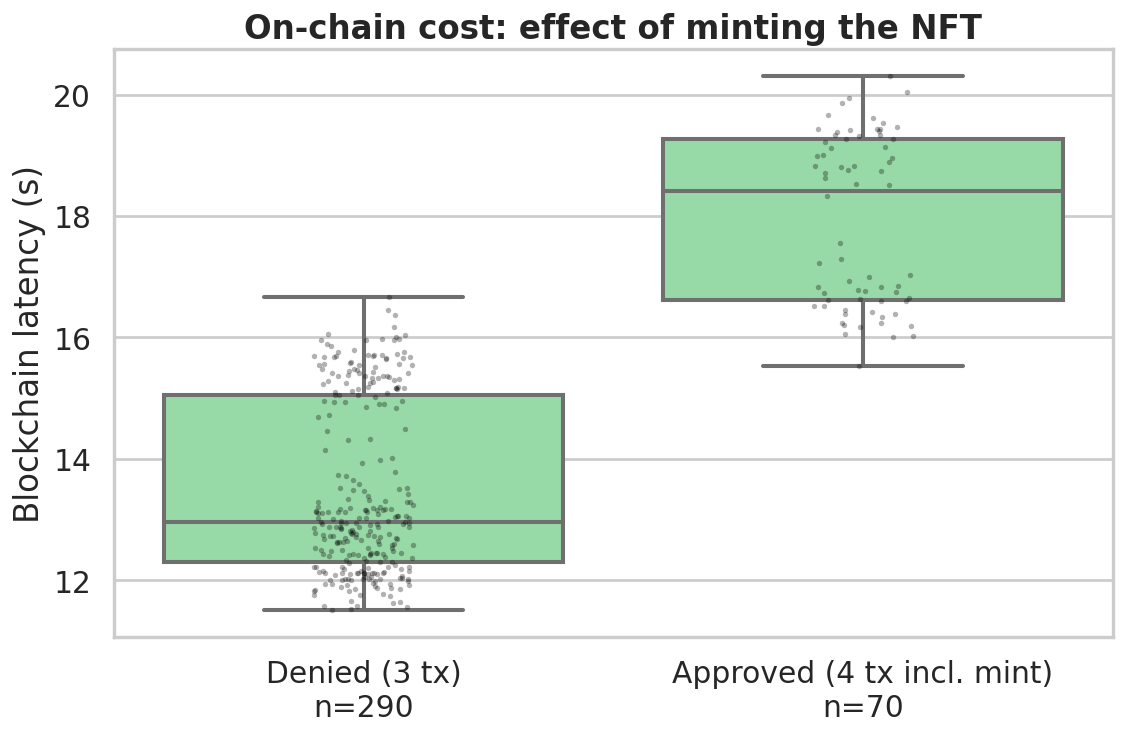

Denied  : 13.46 ± 1.41 s (n=290)
Approved: 17.92 ± 1.39 s (n=70)
Difference (mint cost): 4.46 s
Mann-Whitney U = 20213, p = 3.055e-38
=> Approved sessions are significantly slower (the mint adds cost).


In [8]:
appr = df[df["decision"] == "approved"]["blockchain"]
deny = df[df["decision"] == "denied"]["blockchain"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x="decision", y="blockchain",
            order=["denied", "approved"], ax=ax, color=sns.color_palette("pastel")[2])
sns.stripplot(data=df, x="decision", y="blockchain",
              order=["denied", "approved"], color="black", alpha=0.3, size=3, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Blockchain latency (s)")
ax.set_xticklabels([f"Denied (3 tx)\nn={len(deny)}", f"Approved (4 tx incl. mint)\nn={len(appr)}"])
ax.set_title("On-chain cost: effect of minting the NFT")
fig.tight_layout()
fig.savefig(OUT / "mint_cost.png")
plt.show()

U, p = stats.mannwhitneyu(appr, deny, alternative="greater")
delta = appr.mean() - deny.mean()
print(f"Denied  : {deny.mean():.2f} ± {deny.std():.2f} s (n={len(deny)})")
print(f"Approved: {appr.mean():.2f} ± {appr.std():.2f} s (n={len(appr)})")
print(f"Difference (mint cost): {delta:.2f} s")
print(f"Mann-Whitney U = {U:.0f}, p = {p:.3e}")
print("=> Approved sessions are significantly slower (the mint adds cost)."
      if p < 0.05 else "=> No significant difference.")


## 8. Correlation between phases

Checks whether the phases vary together (e.g. slower runs affect everything) or
independently.


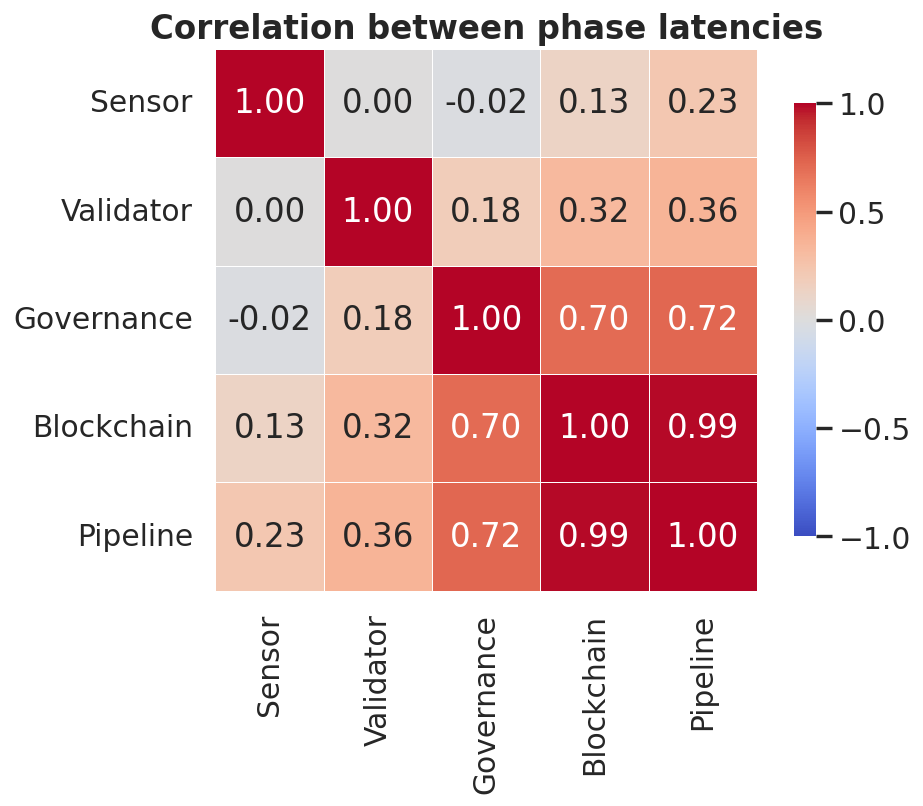

In [9]:
corr = df[PHASES + ["pipeline_s"]].rename(
    columns={**PHASE_LABEL, "pipeline_s": "Pipeline"}).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation between phase latencies")
fig.tight_layout()
fig.savefig(OUT / "phase_correlation.png")
plt.show()


## 9. Summary of findings

In [10]:
m = df[PHASES].mean()
tot = m.sum()
print("=" * 60)
print("SUMMARY — LATENCY (5 runs, n={} sessions)".format(len(df)))
print("=" * 60)
print(f"Mean end-to-end latency  : {df['elapsed_s'].mean():.1f} s "
      f"(median {df['elapsed_s'].median():.1f}, p95 {df['elapsed_s'].quantile(.95):.1f})")
print(f"Dominant phase           : Blockchain ({100*m['blockchain']/tot:.0f}% of the time)")
print(f"Agentic time (3 LLMs)    : {m[['sensor','validator','governance']].sum():.1f} s "
      f"({100*m[['sensor','validator','governance']].sum()/tot:.0f}%)")
print(f"Minting cost (mint)      : +{appr.mean()-deny.mean():.1f} s in approved sessions")
print(f"Stability across runs    : pipeline CV = "
      f"{100*df['pipeline_s'].std()/df['pipeline_s'].mean():.1f}%")
print("\nArtifacts saved to:", OUT.as_posix())


SUMMARY — LATENCY (5 runs, n=360 sessions)
Mean end-to-end latency  : 26.3 s (median 25.1, p95 31.1)
Dominant phase           : Blockchain (59% of the time)
Agentic time (3 LLMs)    : 9.9 s (41%)
Minting cost (mint)      : +4.5 s in approved sessions
Stability across runs    : pipeline CV = 10.3%

Artifacts saved to: ../results/results_v2_1/latency_analysis
